<a href="https://colab.research.google.com/github/sila85/production_ml_demo/blob/main/IMDb9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load only the top 10,000 most frequent words
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = \
    imdb.load_data(num_words=vocab_size)

# Pad sequences to ensure uniform input length
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test  = pad_sequences(X_test,  maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM,
                                     Bidirectional, Dense, Dropout)

model = Sequential([
    # Embedding layer maps word indices to dense 128-dimensional vectors
    Embedding(input_dim=vocab_size, output_dim=128,
              input_length=max_len),
    # Bidirectional LSTM: 64 units each direction (128 total)
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [3]:
# Train for 5 epochs with a batch size of 64
history = model.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_split=0.2)

# Evaluate on unseen test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 336ms/step - accuracy: 0.7459 - loss: 0.5164 - val_accuracy: 0.8186 - val_loss: 0.4133
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 350ms/step - accuracy: 0.8579 - loss: 0.3395 - val_accuracy: 0.8390 - val_loss: 0.3716
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 335ms/step - accuracy: 0.8949 - loss: 0.2680 - val_accuracy: 0.8564 - val_loss: 0.3498
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 334ms/step - accuracy: 0.9130 - loss: 0.2259 - val_accuracy: 0.8532 - val_loss: 0.3830
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 349ms/step - accuracy: 0.9312 - loss: 0.1803 - val_accuracy: 0.8466 - val_loss: 0.4036
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8438 - loss: 0.4091
Test Accuracy: 0.8438


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Generate Data
t = np.linspace(0, 100, 1000)
data = np.sin(t)

# 2. Prepare sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
# Reshape for LSTM (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# 3. Build Model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 4. Train
model.fit(X, y, epochs=20, verbose=0)

# 5. Predict
test_seq = data[-seq_length:].reshape((1, seq_length, 1))
prediction = model.predict(test_seq)
print(f"Next predicted sine value: {prediction[0][0]:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Next predicted sine value: -0.4071


In [5]:
import os
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile

uri = ("https://storage.googleapis.com/tensorflow/"
       "tf-keras-datasets/jena_climate_2009_2016.csv.zip")
zip_path = keras.utils.get_file(
    origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


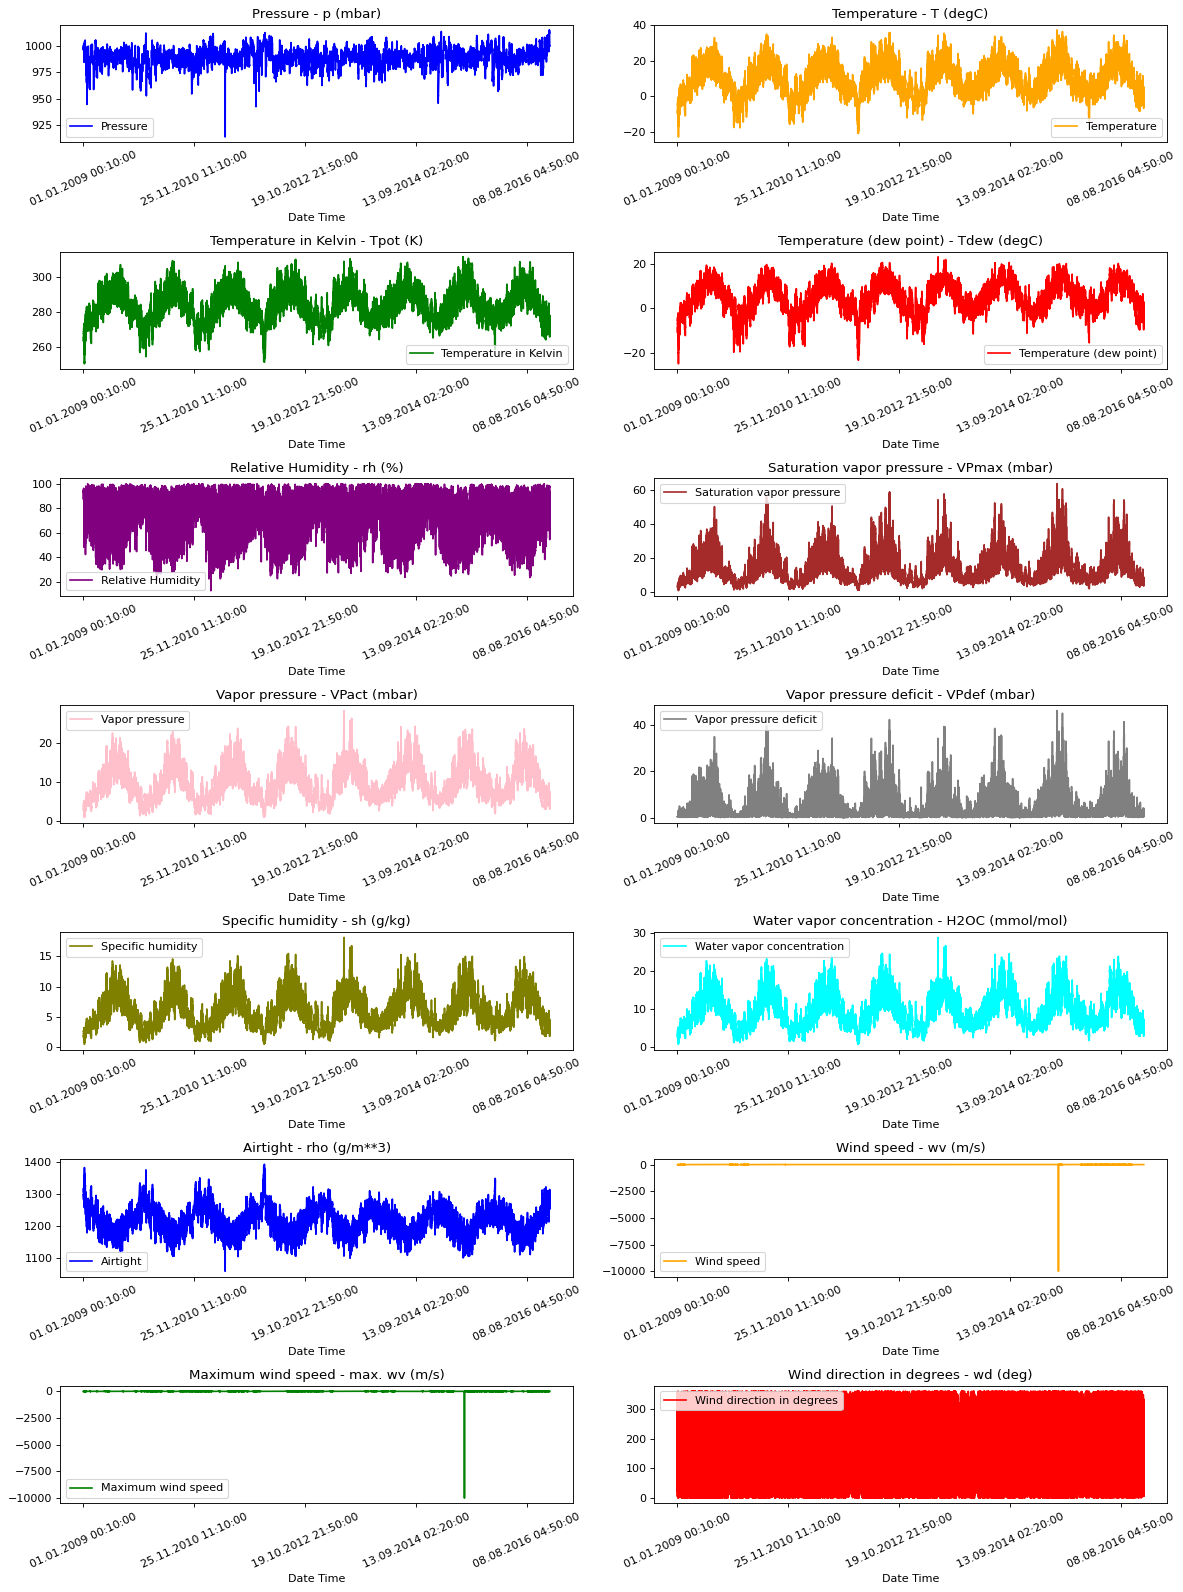

In [7]:
titles = [
    "Pressure", "Temperature", "Temperature in Kelvin",
    "Temperature (dew point)", "Relative Humidity",
    "Saturation vapor pressure", "Vapor pressure",
    "Vapor pressure deficit", "Specific humidity",
    "Water vapor concentration", "Airtight",
    "Wind speed", "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)",
    "rh (%)", "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)",
    "sh (g/kg)", "H2OC (mmol/mol)", "rho (g/m**3)",
    "wv (m/s)", "max. wv (m/s)", "wd (deg)",
]

colors = ["blue","orange","green","red","purple","brown",
          "pink","gray","olive","cyan"]
date_time_key = "Date Time"

def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(nrows=7, ncols=2,
                             figsize=(15, 20), dpi=80)
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % len(colors)]
        t_data = data[key]
        t_data.index = time_data
        ax = t_data.plot(ax=axes[i // 2, i % 2], color=c,
            title="{} - {}".format(titles[i], key), rot=25)
        ax.legend([titles[i]])
    plt.tight_layout()

show_raw_visualization(df)

In [9]:
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))
step = 6

past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10

def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std  = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

In [10]:
print("The selected parameters are:",
      ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]))
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

train_data = features.loc[0 : train_split - 1]
val_data   = features.loc[train_split:]

The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


In [12]:
start = past + future
end   = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train, y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

In [13]:
x_end       = len(val_data) - past - future
label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val, y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


In [14]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.GRU(32, input_shape=(sequence_length, 7)),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')

history = model.fit(
    dataset_train, epochs=5,
    validation_data=dataset_val,
)

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 123s 104ms/step - loss: 0.2459 - val_loss: 0.1867
Epoch 2/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 143s 104ms/step - loss: 0.1367 - val_loss: 0.1390
Epoch 3/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 121s 103ms/step - loss: 0.1156 - val_loss: 0.1278
Epoch 4/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 121s 103ms/step - loss: 0.1086 - val_loss: 0.1256
Epoch 5/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 122s 104ms/step - loss: 0.1051 - val_loss: 0.1250


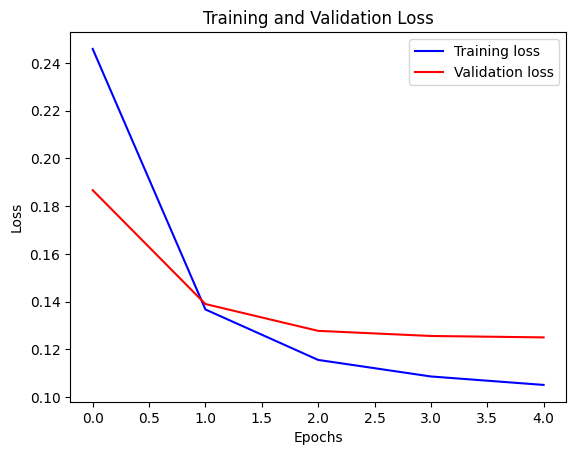

In [15]:
def visualize_loss(history, title):
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs   = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

visualize_loss(history, "Training and Validation Loss")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


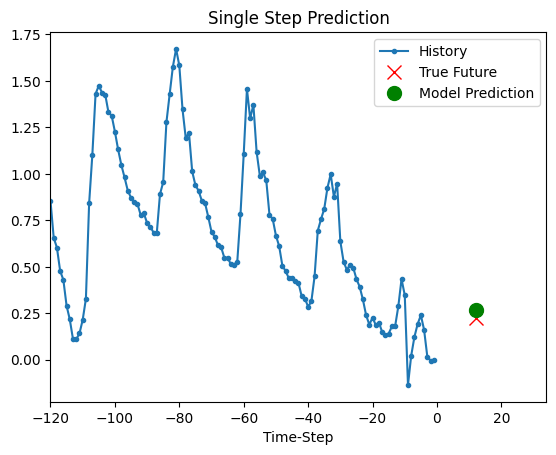

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


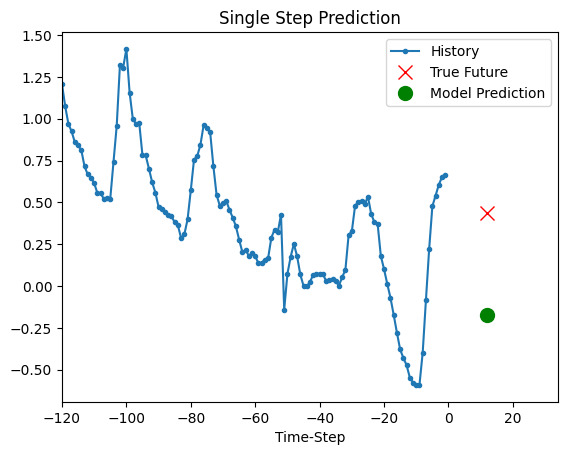

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


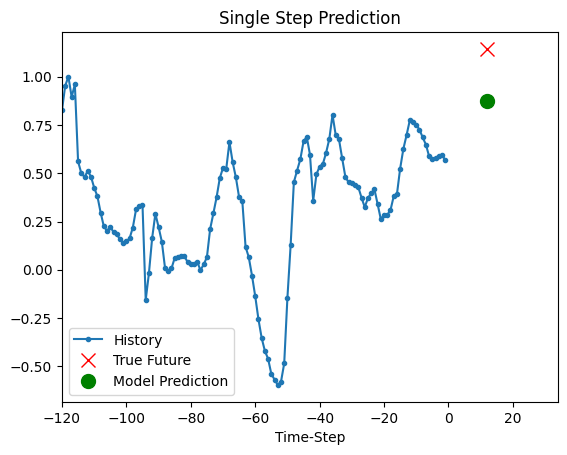

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


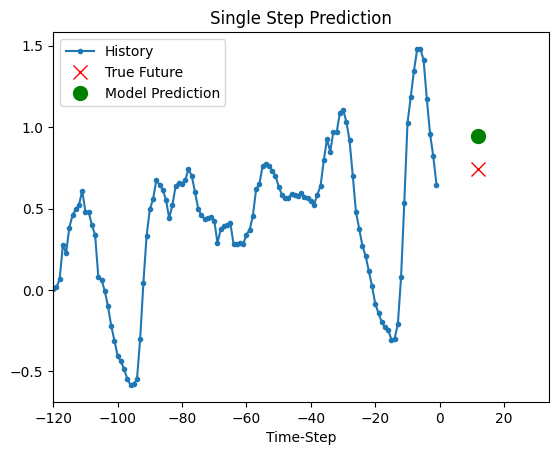

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


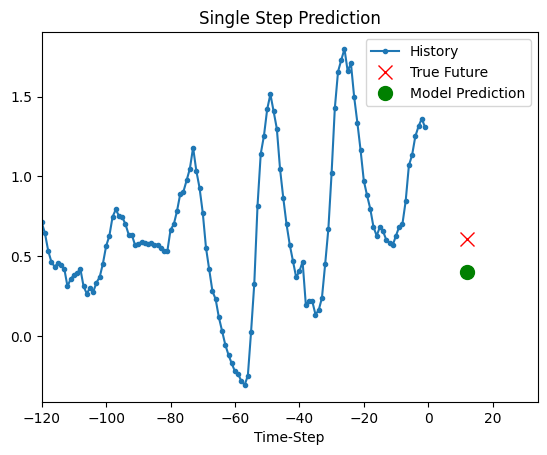

In [16]:
def show_plot(plot_data, delta, title):
    labels     = ["History", "True Future", "Model Prediction"]
    marker     = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    future = delta if delta else 0
    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i],
                     markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(),
                     marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()

for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    # Embedding layer maps word indices to dense 128-dimensional vectors
    Embedding(input_dim=vocab_size, output_dim=128,
              input_length=max_len),

    # Standard LSTM: 64 units
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Train for 5 epochs with a batch size of 64
history = model.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_split=0.2)

# Evaluate on unseen test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 176ms/step - accuracy: 0.0000e+00 - loss: -8.2009 - val_accuracy: 0.0000e+00 - val_loss: 16.0613
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.0000e+00 - loss: -18.5902 - val_accuracy: 0.0000e+00 - val_loss: 27.2418
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 177ms/step - accuracy: 0.0000e+00 - loss: -28.1105 - val_accuracy: 0.0000e+00 - val_loss: 38.2713
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 177ms/step - accuracy: 0.0000e+00 - loss: -37.5114 - val_accuracy: 0.0000e+00 - val_loss: 49.1784
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.0000e+00 - loss: -46.8279 - val_accuracy: 0.0000e+00 - val_loss: 59.9808
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5000 - loss: 55.2107
Test Accuracy: 0.5000


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

model = Sequential([
    # Embedding layer maps word indices to dense 128-dimensional vectors
    Embedding(input_dim=vocab_size, output_dim=128,
              input_length=max_len),

    # GRU: 64 units
    GRU(64, dropout=0.2, recurrent_dropout=0.2),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
# Train for 5 epochs with a batch size of 64
history = model.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_split=0.2)

# Evaluate on unseen test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 187ms/step - accuracy: 0.0000e+00 - loss: -9.3222 - val_accuracy: 0.0000e+00 - val_loss: 17.2752
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 183ms/step - accuracy: 0.0000e+00 - loss: -19.5444 - val_accuracy: 0.0000e+00 - val_loss: 28.3005
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step - accuracy: 0.0000e+00 - loss: -28.9399 - val_accuracy: 0.0000e+00 - val_loss: 39.2010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 183ms/step - accuracy: 0.0000e+00 - loss: -38.2884 - val_accuracy: 0.0000e+00 - val_loss: 50.0458
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.0000e+00 - loss: -47.5896 - val_accuracy: 0.0000e+00 - val_loss: 60.8445
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.5000 - loss: 56.0058
Test Accuracy: 0.5000
